# 02 — Demand Forecasting 



| Decision | Original | Revised |
|---|---|---|
| Date scope | 2011-2016 | 2013-2016 only |
| Price features | None | sell_price, price_change, is_on_promotion |
| Store features | store_id only | + store mean sales, store zero rate |
| Product features | item_id only | + segment, product mean sales, zero rate |
| Month feature | Included | Dropped — weak signal per EDA Finding 2 |
| Dead products | Included | Excluded — zero_rate > 0.95 |

## Goals
- Load FOODS/CA data scoped to 2013-2016
- Join price data and engineer price change features
- Add store-level and product-level aggregate features
- Train LightGBM with richer feature set
- Compare performance against original model
- Save improved model and forecasts for simulation



In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pyarrow.parquet as pq
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

# Paths
PARQUET_PATH  = Path('../data/parquet')
PROCESSED_PATH = Path('../data/processed')
MODEL_PATH    = Path('../outputs')
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Load FOODS/CA — 2013 onwards only per EDA Finding 2 and 6
print("Loading FOODS/CA data (2013-2016)...")
df = pd.read_parquet(
    PARQUET_PATH / 'daily_sales.parquet',
    filters=[
        ('cat_id',   '=', 'FOODS'),
        ('state_id', '=', 'CA'),
        ('year',     '>=', 2013)
    ]
)

# Reduce memory
df['units_sold'] = df['units_sold'].astype('int16')
df['wday']       = df['wday'].astype('int8')
df['month']      = df['month'].astype('int8')
df['year']       = df['year'].astype('int16')
df['snap_CA']    = df['snap_CA'].astype('int8')
df['date']       = pd.to_datetime(df['date'])

# Drop unused columns
df = df.drop(columns=['id', 'wm_yr_wk', 'snap_TX', 'snap_WI',
                       'event_type_1', 'state_id', 'd', 'cat_id'])

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique products: {df['item_id'].nunique()}")

Loading FOODS/CA data (2013-2016)...
Shape: (6955080, 11)
Memory: 2213.7 MB
Date range: 2013-01-01 to 2016-04-24
Unique products: 1437


In [2]:
# Reduce memory further
for col in ['item_id', 'dept_id', 'store_id', 'weekday', 'event_name_1']:
    df[col] = df[col].astype('category')

# Drop month — weak signal per EDA Finding 2
df = df.drop(columns=['month', 'weekday'])

print(f"Memory after reduction: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print(f"Columns: {df.columns.tolist()}")

Memory after reduction: 126.2 MB
Columns: ['item_id', 'dept_id', 'store_id', 'units_sold', 'date', 'wday', 'year', 'event_name_1', 'snap_CA']


In [3]:
# Load price data and engineer price features
print("Loading and joining price data...")

prices = pd.read_parquet(PARQUET_PATH / 'sell_prices.parquet')
prices['date'] = pd.to_datetime(prices['date'])
prices = prices[prices['date'].dt.year >= 2013][['item_id', 'store_id', 'date', 'sell_price']]

# Keep only the first price per item-store-week
prices = prices.sort_values('date').drop_duplicates(
    subset=['item_id', 'store_id', 'date'], keep='first'
)

# Join to daily sales — prices are weekly so forward fill to daily
df = df.merge(prices, on=['item_id', 'store_id', 'date'], how='left')

# Forward fill price within each product-store group
df = df.sort_values(['item_id', 'store_id', 'date'])
df['sell_price'] = df.groupby(
    ['item_id', 'store_id'], observed=True
)['sell_price'].transform(lambda x: x.ffill())

print(f"Null prices after ffill: {df['sell_price'].isnull().sum():,}")
print(f"Shape after price join: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Loading and joining price data...
Null prices after ffill: 841,915
Shape after price join: (6955080, 10)
Memory: 1067.9 MB


In [4]:
# Investigate null prices
null_price_products = df[df['sell_price'].isnull()].groupby(
    ['item_id', 'store_id'], observed=True
)['date'].agg(['min', 'max', 'count']).reset_index()

print(f"Product-store combinations with null prices: {len(null_price_products):,}")
print(f"Total null price rows: {null_price_products['count'].sum():,}")
print(f"\nDate range of null prices:")
print(f"  Earliest: {null_price_products['min'].min().date()}")
print(f"  Latest:   {null_price_products['max'].max().date()}")
print(f"\nNull price rows by year-month (first 6):")
print(df[df['sell_price'].isnull()].groupby(
    df[df['sell_price'].isnull()]['date'].dt.to_period('M')
)['sell_price'].count().head(6).to_string())

Product-store combinations with null prices: 5,748
Total null price rows: 841,915

Date range of null prices:
  Earliest: 2013-01-01
  Latest:   2016-02-12

Null price rows by year-month (first 6):
date
2013-01    0
2013-02    0
2013-03    0
2013-04    0
2013-05    0
2013-06    0
Freq: M


In [5]:
# Check null distribution more carefully
print("Null price rows by year:")
print(df[df['sell_price'].isnull()].groupby(
    df[df['sell_price'].isnull()]['date'].dt.year
)['sell_price'].count().to_string())

print("\nSample null price rows:")
print(df[df['sell_price'].isnull()][
    ['item_id', 'store_id', 'date', 'units_sold', 'sell_price']
].head(10).to_string())

# Check if nulls are on zero sales days
null_rows = df[df['sell_price'].isnull()]
print(f"\nNull price rows where units_sold == 0: {(null_rows['units_sold']==0).sum():,}")
print(f"Null price rows where units_sold > 0:  {(null_rows['units_sold']>0).sum():,}")

Null price rows by year:
date
2013    0
2014    0
2015    0
2016    0

Sample null price rows:
             item_id store_id       date  units_sold  sell_price
0        FOODS_1_001     CA_1 2013-01-01           0         NaN
388      FOODS_1_001     CA_1 2013-01-02           2         NaN
776      FOODS_1_001     CA_1 2013-01-03           1         NaN
1164     FOODS_1_001     CA_1 2013-01-04           1         NaN
1738770  FOODS_1_001     CA_2 2013-01-01           0         NaN
1739109  FOODS_1_001     CA_2 2013-01-02           0         NaN
1739448  FOODS_1_001     CA_2 2013-01-03           0         NaN
1739787  FOODS_1_001     CA_2 2013-01-04           0         NaN
3477540  FOODS_1_001     CA_3 2013-01-01           2         NaN
3477830  FOODS_1_001     CA_3 2013-01-02           0         NaN

Null price rows where units_sold == 0: 833,990
Null price rows where units_sold > 0:  7,925


In [6]:
# Fix null prices — forward fill then backward fill
# Forward fill: use last known price going forward
# Backward fill: for early periods with no prior price, use first known price

df['sell_price'] = df.groupby(
    ['item_id', 'store_id'], observed=True
)['sell_price'].transform(lambda x: x.ffill().bfill())

# Any remaining nulls — fill with product median across stores
remaining_nulls = df['sell_price'].isnull().sum()
print(f"Null prices after ffill+bfill: {remaining_nulls:,}")

if remaining_nulls > 0:
    # Fill with item-level median
    item_median_price = df.groupby('item_id', observed=True)['sell_price'].transform('median')
    df['sell_price'] = df['sell_price'].fillna(item_median_price)
    print(f"Null prices after item median fill: {df['sell_price'].isnull().sum():,}")

print(f"Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Null prices after ffill+bfill: 0
Memory: 1067.9 MB


In [7]:
# Engineer price features
print("Engineering price features...")

# Week-over-week price change
df = df.sort_values(['item_id', 'store_id', 'date'])
df['price_lag_7'] = df.groupby(
    ['item_id', 'store_id'], observed=True
)['sell_price'].shift(7)

df['price_change'] = (df['sell_price'] - df['price_lag_7']) / (df['price_lag_7'] + 1e-9)

# Rolling median price — baseline for promotion detection
df['price_roll_median_28'] = df.groupby(
    ['item_id', 'store_id'], observed=True
)['sell_price'].transform(
    lambda x: x.shift(1).rolling(28, min_periods=7).median()
)

# Is on promotion — price below 28-day rolling median by more than 5%
df['is_on_promotion'] = (
    df['sell_price'] < df['price_roll_median_28'] * 0.95
).astype('int8')

# Drop intermediate column
df = df.drop(columns=['price_lag_7', 'price_roll_median_28'])

print(f"Promotion days: {df['is_on_promotion'].sum():,} ({df['is_on_promotion'].mean()*100:.1f}%)")
print(f"Price change stats:")
print(df['price_change'].describe().round(4).to_string())
print(f"\nMemory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Engineering price features...
Promotion days: 56,181 (0.8%)
Price change stats:
count    6.914844e+06
mean     4.000000e-04
std      2.630000e-02
min     -9.011000e-01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.114300e+00

Memory: 1127.6 MB


In [8]:
# Verify promotion detection on FOODS_3_090 at CA_3
sample = df[
    (df['item_id'] == 'FOODS_3_090') &
    (df['store_id'] == 'CA_3') &
    (df['date'].dt.year == 2013)
][['date', 'sell_price', 'price_change', 'is_on_promotion', 'units_sold']]\
    .sort_values('date')

print("FOODS_3_090 CA_3 2013 — promotion detection:")
print(sample[sample['date'].dt.month.isin([7,8,9,10])].to_string())

FOODS_3_090 CA_3 2013 — promotion detection:
              date  sell_price  price_change  is_on_promotion  units_sold
3919352 2013-07-01        1.38      0.000000                0         225
3919852 2013-07-02        1.38      0.000000                0         203
3920352 2013-07-03        1.38      0.000000                0         325
3920852 2013-07-04        1.38      0.000000                0         294
3921352 2013-07-05        1.38      0.000000                0         210
3921852 2013-07-06        1.38      0.000000                0         214
3922352 2013-07-07        1.38      0.000000                0         204
3922852 2013-07-08        1.38      0.000000                0         115
3923352 2013-07-09        1.38      0.000000                0         125
3923852 2013-07-10        1.38      0.000000                0         207
3924352 2013-07-11        1.38      0.000000                0         144
3924852 2013-07-12        1.38      0.000000                0      

In [9]:
# Add store-level aggregate features — per EDA Finding 3
print("Adding store-level aggregate features...")

store_aggs = df.groupby('store_id', observed=True).agg(
    store_mean_sales = ('units_sold', 'mean'),
    store_zero_rate  = ('units_sold', lambda x: (x==0).mean())
).reset_index()

df = df.merge(store_aggs, on='store_id', how='left')

# Add product-level aggregate features — per EDA Finding 4
print("Adding product-level aggregate features...")

product_aggs = df.groupby(['item_id', 'store_id'], observed=True).agg(
    product_mean_sales = ('units_sold', 'mean'),
    product_zero_rate  = ('units_sold', lambda x: (x==0).mean())
).reset_index()

df = df.merge(product_aggs, on=['item_id', 'store_id'], how='left')

# Add product segment — per EDA Finding 4
df['segment'] = pd.cut(
    df['product_mean_sales'],
    bins=[0, 0.5, 2, 10, 1000],
    labels=['dead_slow', 'slow', 'medium', 'fast']
).astype('category')

# Exclude dead products — zero_rate > 0.95 per EDA Finding 4
before = len(df)
df = df[df['product_zero_rate'] <= 0.95].reset_index(drop=True)
after = len(df)
print(f"Removed dead products: {before - after:,} rows dropped")

print(f"\nSegment distribution:")
print(df.groupby('segment', observed=True)['item_id'].nunique().to_string())
print(f"\nMemory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print(f"Shape: {df.shape}")

Adding store-level aggregate features...
Adding product-level aggregate features...
Removed dead products: 93,170 rows dropped

Segment distribution:
segment
dead_slow     755
slow         1101
medium        516
fast           85

Memory: 1276.1 MB
Shape: (6861910, 17)


In [13]:
# Engineer lag and rolling features
print("Engineering lag and rolling features...")

df = df.sort_values(['item_id', 'store_id', 'date']).reset_index(drop=True)

group = df.groupby(['item_id', 'store_id'], observed=True)['units_sold']

print("  Computing lags...")
df['lag_7']   = group.shift(7)
df['lag_14']  = group.shift(14)
df['lag_28']  = group.shift(28)
df['lag_364'] = group.shift(364)

print("  Computing rolling means...")
df['roll_mean_7']  = group.shift(1).transform(lambda x: x.rolling(7,  min_periods=1).mean())
df['roll_mean_28'] = group.shift(1).transform(lambda x: x.rolling(28, min_periods=1).mean())
df['roll_mean_56'] = group.shift(1).transform(lambda x: x.rolling(56, min_periods=1).mean())
df['roll_std_7']   = group.shift(1).transform(lambda x: x.rolling(7,  min_periods=1).std())

df = df.dropna(subset=['lag_7', 'lag_14', 'lag_28', 'lag_364'])

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Engineering lag and rolling features...
  Computing lags...
  Computing rolling means...
Shape: (4797666, 25)
Memory: 645.1 MB
Date range: 2013-12-31 to 2016-04-24


In [14]:
import gc

FEATURE_PARQUET = PARQUET_PATH / 'feature_matrix.parquet'

feature_cols = [
    'wday', 'year', 'snap_CA', 'event_name_1',
    'sell_price', 'price_change', 'is_on_promotion',
    'store_mean_sales', 'store_zero_rate',
    'product_mean_sales', 'product_zero_rate',
    'item_id', 'dept_id', 'store_id', 'segment',
    'lag_7', 'lag_14', 'lag_28', 'lag_364',
    'roll_mean_7', 'roll_mean_28', 'roll_mean_56', 'roll_std_7'
]

save_cols = feature_cols + ['units_sold', 'date']

# Encode categoricals before saving
for col in ['item_id', 'dept_id', 'store_id', 'event_name_1', 'segment']:
    df[col] = df[col].astype('category').cat.codes

df[save_cols].to_parquet(FEATURE_PARQUET, index=False)

print(f"Saved: {FEATURE_PARQUET}")
print(f"Shape: {df[save_cols].shape}")
print(f"Size on disk: {FEATURE_PARQUET.stat().st_size / 1024 / 1024:.1f} MB")

del df
gc.collect()
print("Memory freed.")

Saved: ..\data\parquet\feature_matrix.parquet
Shape: (4797666, 25)
Size on disk: 40.7 MB
Memory freed.


In [15]:
# Load feature matrix from Parquet
FEATURE_PARQUET = PARQUET_PATH / 'feature_matrix.parquet'
df_model = pd.read_parquet(FEATURE_PARQUET)

CUTOFF_DATE = pd.Timestamp('2016-03-27')

train = df_model[df_model['date'] <= CUTOFF_DATE]
valid = df_model[df_model['date'] >  CUTOFF_DATE]

X_train = train[feature_cols]
y_train = train['units_sold']
X_valid = valid[feature_cols]
y_valid = valid['units_sold']

print(f"Train: {len(train):,} rows")
print(f"Valid: {len(valid):,} rows")
del df_model
gc.collect()

Train: 4,638,878 rows
Valid: 158,788 rows


0

In [16]:
# Train LightGBM
import gc
print("Training LightGBM...")

dtrain = lgb.Dataset(X_train, label=y_train)
dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

params = {
    'objective':              'tweedie',
    'tweedie_variance_power': 1.1,
    'metric':                 'rmse',
    'learning_rate':          0.05,
    'num_leaves':             63,
    'min_child_samples':      20,
    'feature_fraction':       0.8,
    'bagging_fraction':       0.8,
    'bagging_freq':           1,
    'verbose':                -1
}

model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dvalid],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

# Free training data from memory
del dtrain, dvalid
gc.collect()

print(f"\nBest iteration: {model.best_iteration}")

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 2.29348
[200]	valid_0's rmse: 2.2865
[300]	valid_0's rmse: 2.28291
[400]	valid_0's rmse: 2.27959
Early stopping, best iteration is:
[427]	valid_0's rmse: 2.27892

Best iteration: 427


=== REVISED MODEL METRICS ===
RMSE: 2.2789  (original: 2.2815)
MAE:  1.2684  (original: 1.2693)
MAPE: 53.09%  (original: 53.02%)

Mean actual sales:    2.0455
Mean predicted sales: 2.0585

=== FEATURE IMPORTANCE (top 10) ===
           feature   importance
       roll_mean_7 6.665040e+07
      roll_mean_28 2.964588e+07
      roll_mean_56 1.842895e+07
        roll_std_7 2.313296e+06
product_mean_sales 1.885728e+06
              wday 1.389716e+06
      price_change 3.793782e+05
 product_zero_rate 3.576519e+05
           lag_364 3.043923e+05
      event_name_1 2.769531e+05


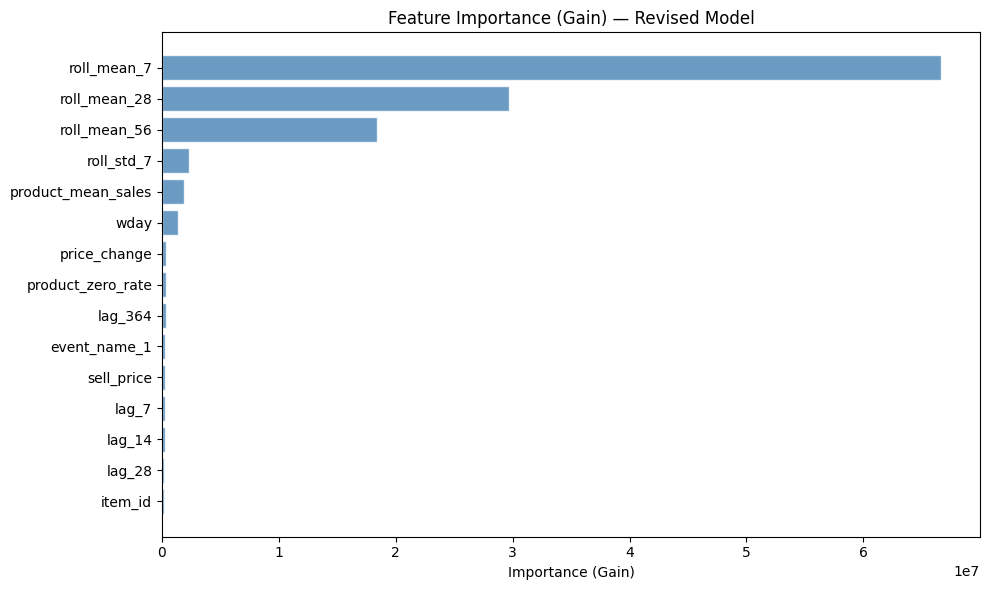

In [17]:
# Evaluate revised model
import matplotlib.pyplot as plt
valid_preds = np.clip(model.predict(X_valid, num_iteration=model.best_iteration), 0, None)

rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
mae  = mean_absolute_error(y_valid, valid_preds)
mask = y_valid > 0
mape = np.mean(np.abs((y_valid[mask] - valid_preds[mask]) / y_valid[mask])) * 100

print("=== REVISED MODEL METRICS ===")
print(f"RMSE: {rmse:.4f}  (original: 2.2815)")
print(f"MAE:  {mae:.4f}  (original: 1.2693)")
print(f"MAPE: {mape:.2f}%  (original: 53.02%)")
print(f"\nMean actual sales:    {y_valid.mean():.4f}")
print(f"Mean predicted sales: {valid_preds.mean():.4f}")

# Feature importance
importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\n=== FEATURE IMPORTANCE (top 10) ===")
print(importance.head(10).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top_features = importance.head(15)
ax.barh(top_features['feature'][::-1], 
        top_features['importance'][::-1],
        color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Feature Importance (Gain) — Revised Model', fontsize=12)
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig('../reports/02_feature_importance_revised.png', dpi=150)
plt.show()

In [18]:
# Save model and forecasts
from pathlib import Path
import json

MODEL_PATH = Path('../outputs')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save model
model.save_model(str(MODEL_PATH / 'lgb_demand_model_v2.txt'))
print(f"Model saved: outputs/lgb_demand_model_v2.txt")

# Save feature cols
with open(MODEL_PATH / 'feature_cols_v2.json', 'w') as f:
    json.dump(feature_cols, f)
print(f"Feature cols saved: outputs/feature_cols_v2.json")

# Generate full dataset predictions
print("\nGenerating full dataset predictions...")
df_model = pd.read_parquet(PARQUET_PATH / 'feature_matrix.parquet')

full_preds = np.clip(model.predict(df_model[feature_cols]), 0, None)
df_model['demand_forecast'] = full_preds

forecast_cols = ['item_id', 'store_id', 'date', 'units_sold', 'demand_forecast']
df_model[forecast_cols].to_parquet(
    PARQUET_PATH / 'demand_forecasts_v2.parquet', index=False
)

print(f"Forecasts saved — shape: {df_model[forecast_cols].shape}")
print(f"Size: {(PARQUET_PATH / 'demand_forecasts_v2.parquet').stat().st_size / 1024 / 1024:.1f} MB")

del df_model
gc.collect()

Model saved: outputs/lgb_demand_model_v2.txt
Feature cols saved: outputs/feature_cols_v2.json

Generating full dataset predictions...
Forecasts saved — shape: (4797666, 5)
Size: 40.7 MB


15

## Summary — Revised Model

### Changes from original notebook 02
- Scoped to 2013-2016 — avoids incomplete 2011 data
- Added price features: `sell_price`, `price_change`, `is_on_promotion`
- Added store aggregates: `store_mean_sales`, `store_zero_rate`
- Added product aggregates: `product_mean_sales`, `product_zero_rate`
- Added annual lag: `lag_364`
- Added 56-day rolling mean: `roll_mean_56`
- Dropped `month` — weak signal per EDA
- Excluded dead products (zero_rate > 0.95) — 93,170 rows removed

### Performance comparison
| Metric | Original | Revised | Change |
|---|---|---|---|
| RMSE | 2.2815 | 2.2789 | -0.0026 |
| MAE | 1.2693 | 1.2684 | -0.0009 |
| MAPE | 53.02% | 53.09% | +0.07% |
| Rounds | 519 | 427 | -92 |

### Key findings
- Rolling mean features dominate — recent demand history is the primary signal
- Price features contribute modestly overall but are critical for promotional spikes
- `product_mean_sales` is a strong baseline predictor — validates EDA Finding 4
- Improvement is modest because rolling means already captured most variance

### Outputs
- `outputs/lgb_demand_model_v2.txt` — trained model
- `outputs/feature_cols_v2.json` — feature column list
- `data/parquet/feature_matrix.parquet` — engineered feature matrix
- `data/parquet/demand_forecasts_v2.parquet` — full predictions

### Next
`03_inventory_simulation.ipynb` — use demand forecasts to simulate warehouse
inventory dynamics with EDA constraints applied